D1-TaLEs-Second-remote\Data1.csv - X-Y 相关性: 0.023729644778671073
D1-TaLEs-Second-remote\Data1.csv - X 数据自相关性: 0.03576785375953504
D1-TaLEs-Second-remote\Data1.csv - Y 数据自相关性: 0.08464416725006368
D1-TaLEs-Second-remote\Data1.csv - 简化卡方值: 47.498431481764094, p 值: 3.168732726593951e-07


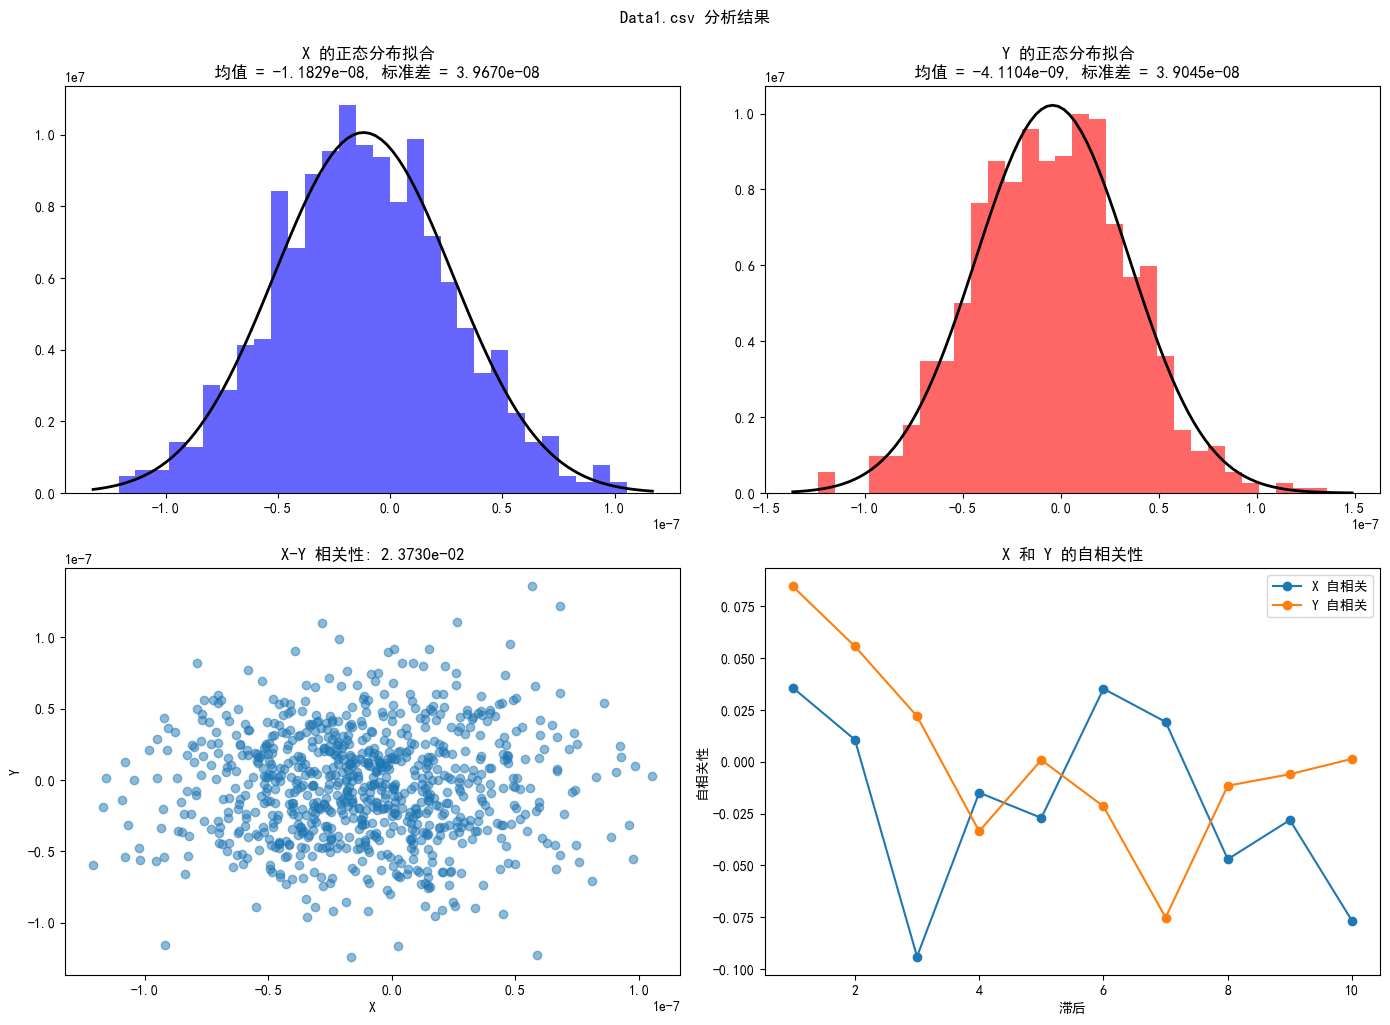

D1-TaLEs-Second-remote\Data2.csv - X-Y 相关性: 0.016766476860152976
D1-TaLEs-Second-remote\Data2.csv - X 数据自相关性: 0.026916908700408828
D1-TaLEs-Second-remote\Data2.csv - Y 数据自相关性: -0.030153838558384577
D1-TaLEs-Second-remote\Data2.csv - 简化卡方值: 203.3065943728044, p 值: 6.712385801218011e-39


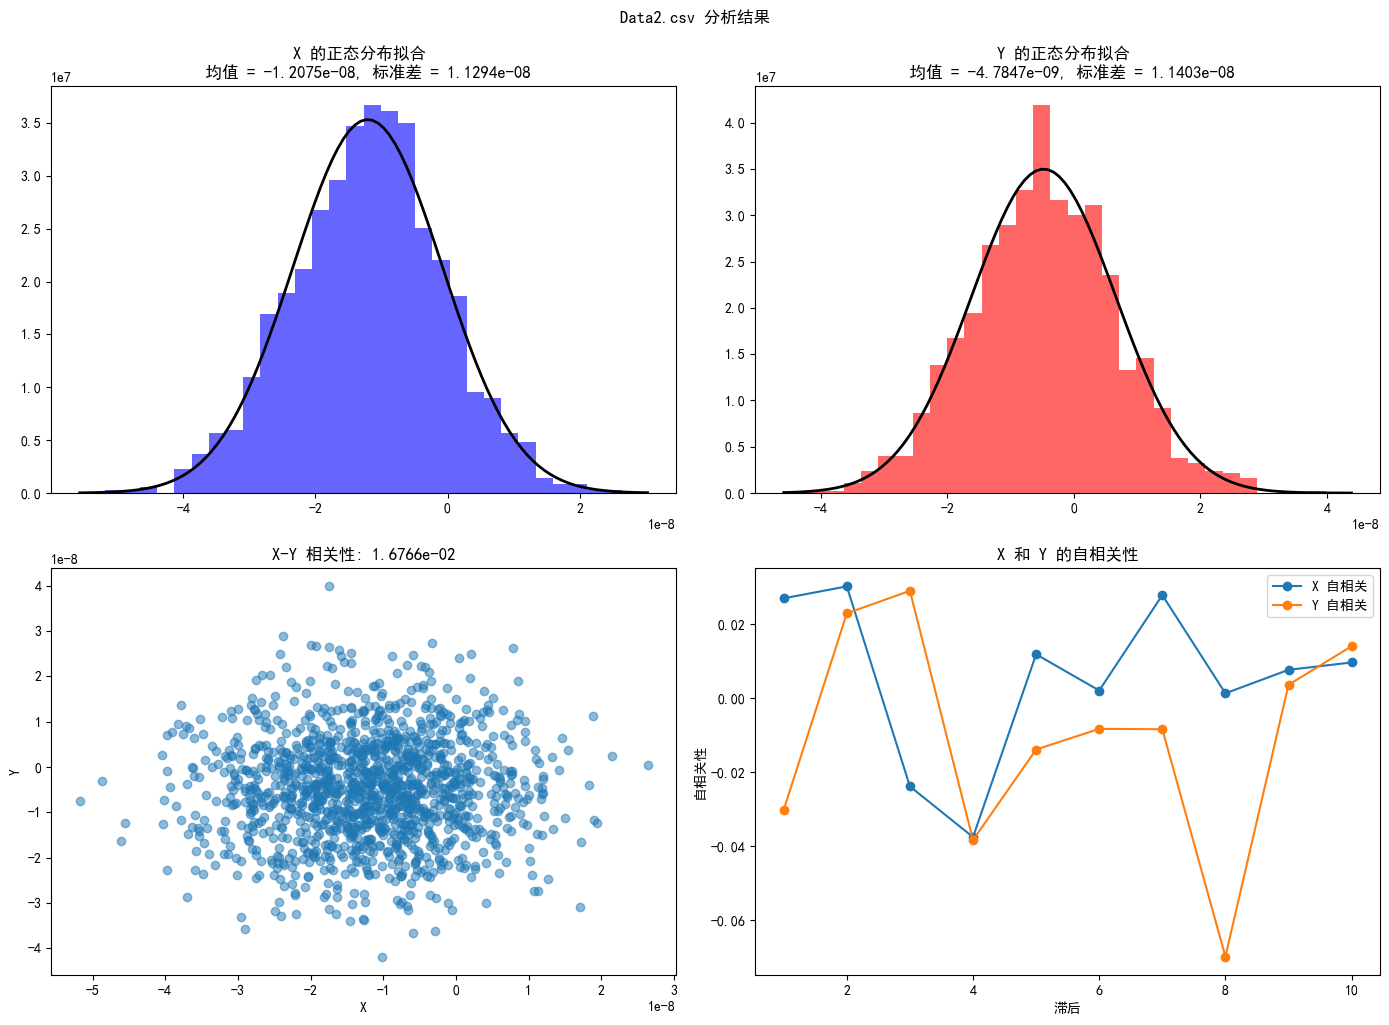

D1-TaLEs-Second-remote\Data3.csv - X-Y 相关性: -0.051915667615347445
D1-TaLEs-Second-remote\Data3.csv - X 数据自相关性: 0.021228987834948965
D1-TaLEs-Second-remote\Data3.csv - Y 数据自相关性: -0.012730814666991289
D1-TaLEs-Second-remote\Data3.csv - 简化卡方值: 36.92699071038197, p 值: 2.7119596112551498e-05


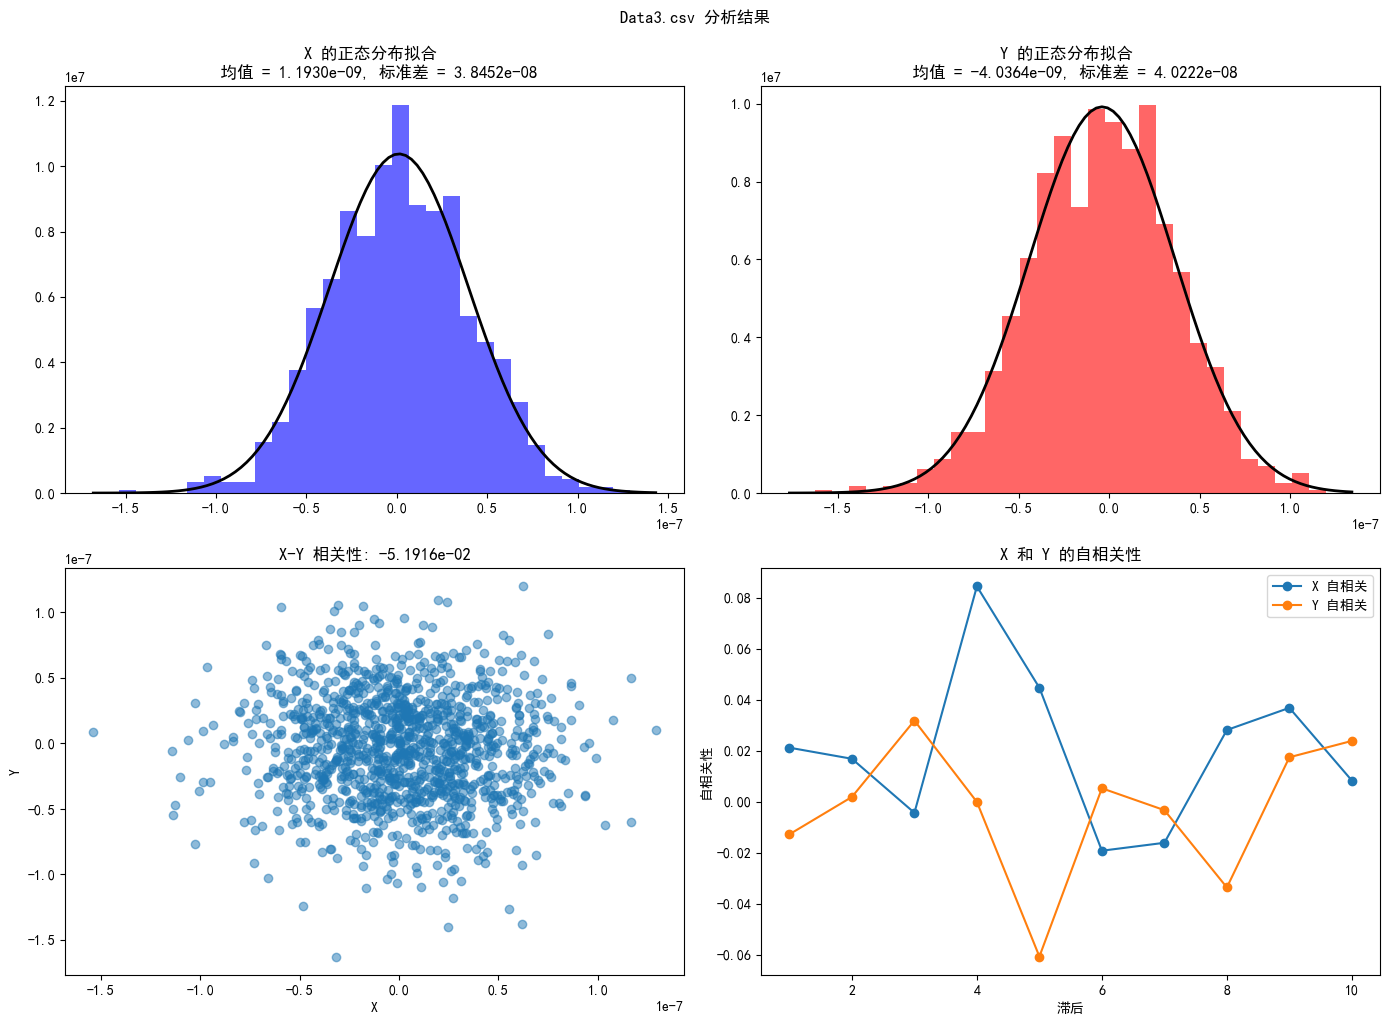

D1-TaLEs-Second-remote\Data4.csv - X-Y 相关性: 0.039577687402613505
D1-TaLEs-Second-remote\Data4.csv - X 数据自相关性: 0.012818667833643129
D1-TaLEs-Second-remote\Data4.csv - Y 数据自相关性: 0.00011060091059388136
D1-TaLEs-Second-remote\Data4.csv - 简化卡方值: 52.36333556559628, p 值: 3.8585867061721636e-08


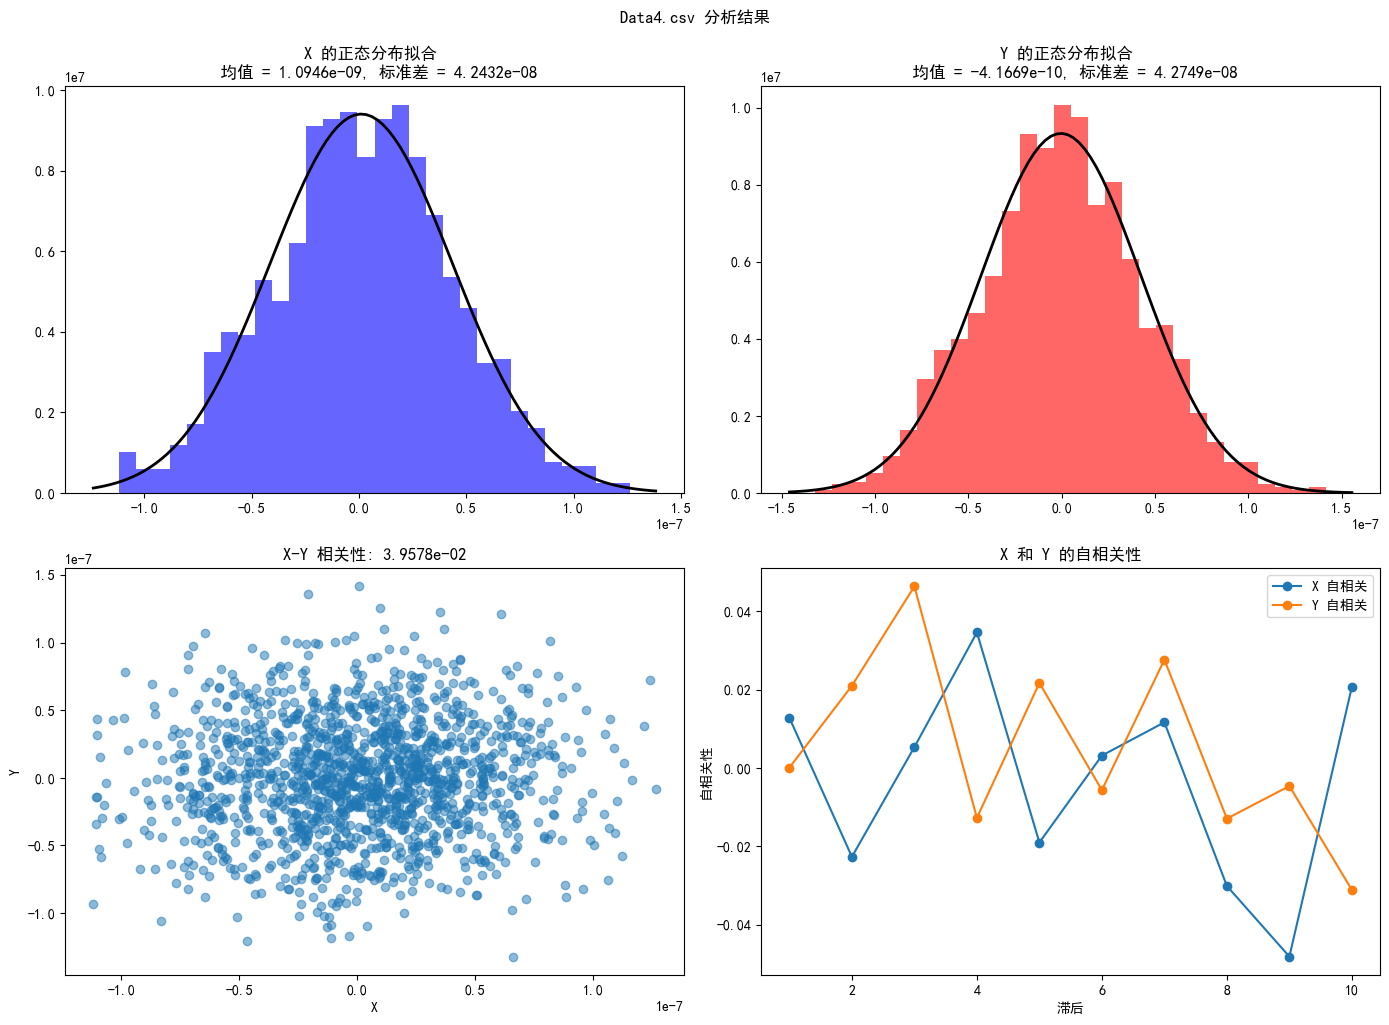

D1-TaLEs-Second-remote\Data5.csv - X-Y 相关性: 0.013624336712442406
D1-TaLEs-Second-remote\Data5.csv - X 数据自相关性: 0.06279384149332275
D1-TaLEs-Second-remote\Data5.csv - Y 数据自相关性: 0.050990904587385054
D1-TaLEs-Second-remote\Data5.csv - 简化卡方值: 69.04315430398037, p 值: 2.3447376651563216e-11


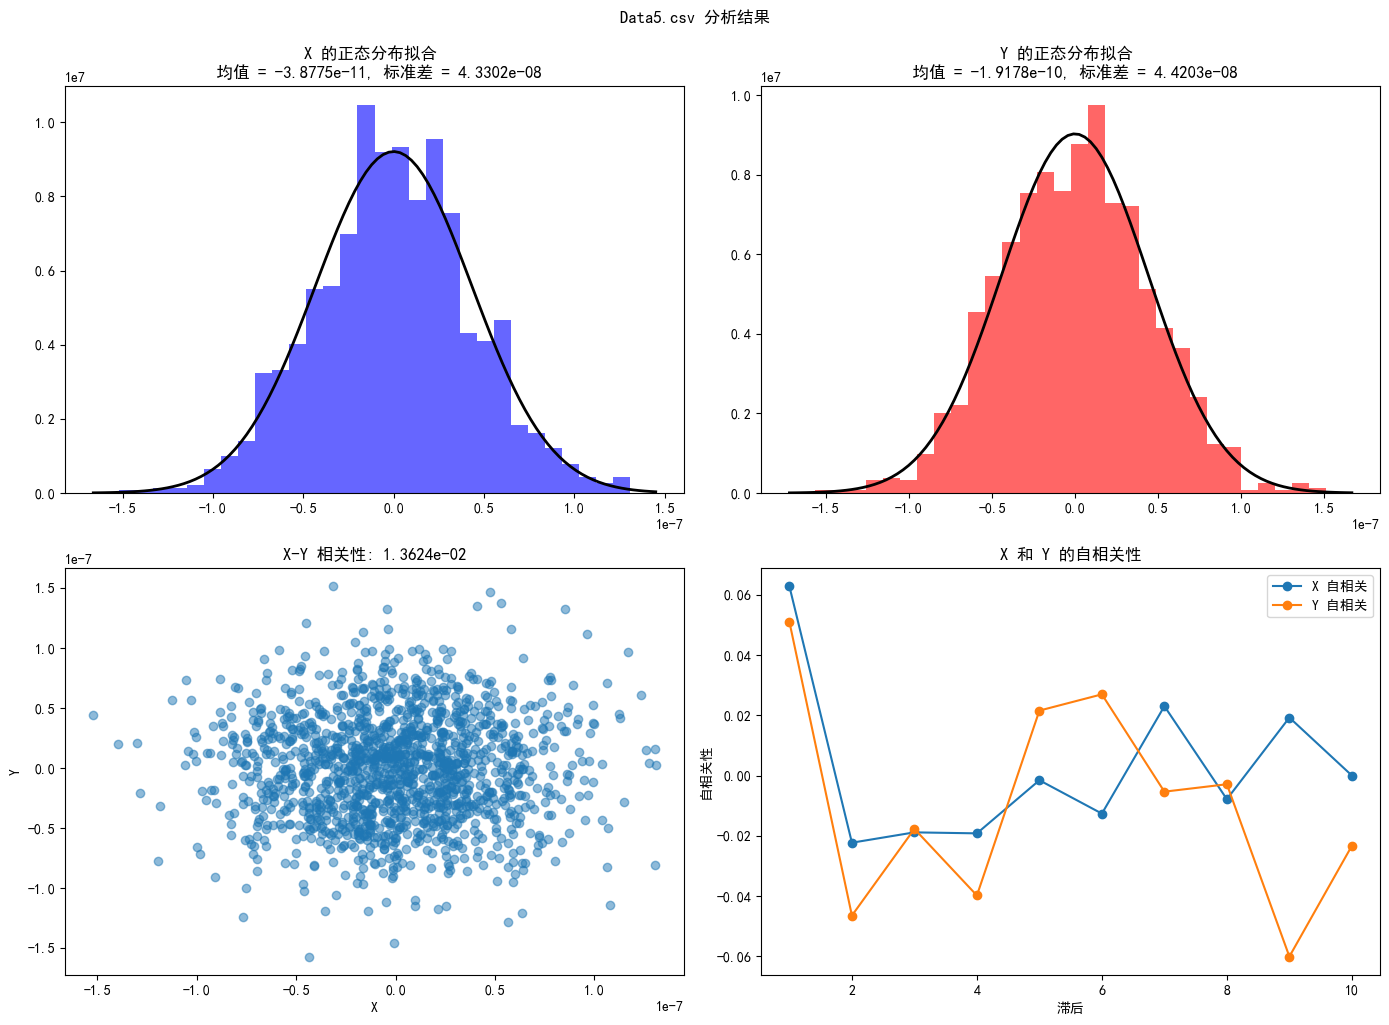

D1-TaLEs-Second-remote\Data6.csv - X-Y 相关性: -0.03504444651216177
D1-TaLEs-Second-remote\Data6.csv - X 数据自相关性: 0.0040938098159011985
D1-TaLEs-Second-remote\Data6.csv - Y 数据自相关性: -0.020246529915682886
D1-TaLEs-Second-remote\Data6.csv - 简化卡方值: 159.90985679544616, p 值: 7.753833907160702e-30


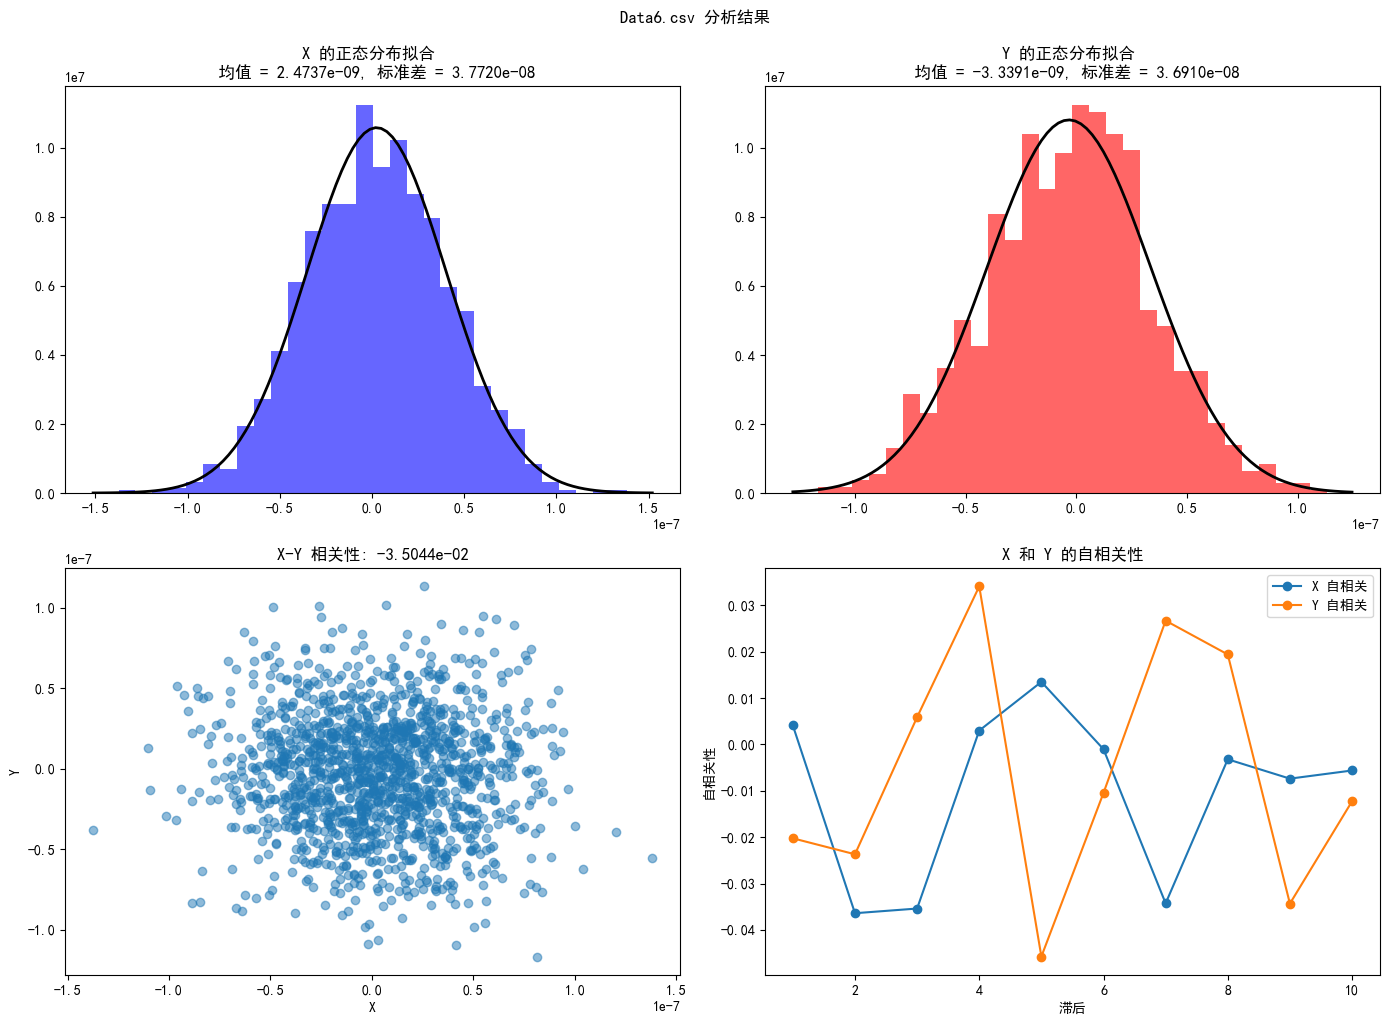

D1-TaLEs-Second-remote\Data7.csv - X-Y 相关性: -0.015100945009429255
D1-TaLEs-Second-remote\Data7.csv - X 数据自相关性: 0.027052954696045406
D1-TaLEs-Second-remote\Data7.csv - Y 数据自相关性: 0.04168708039508319
D1-TaLEs-Second-remote\Data7.csv - 简化卡方值: 31.145386936080037, p 值: 0.0002795016666489084


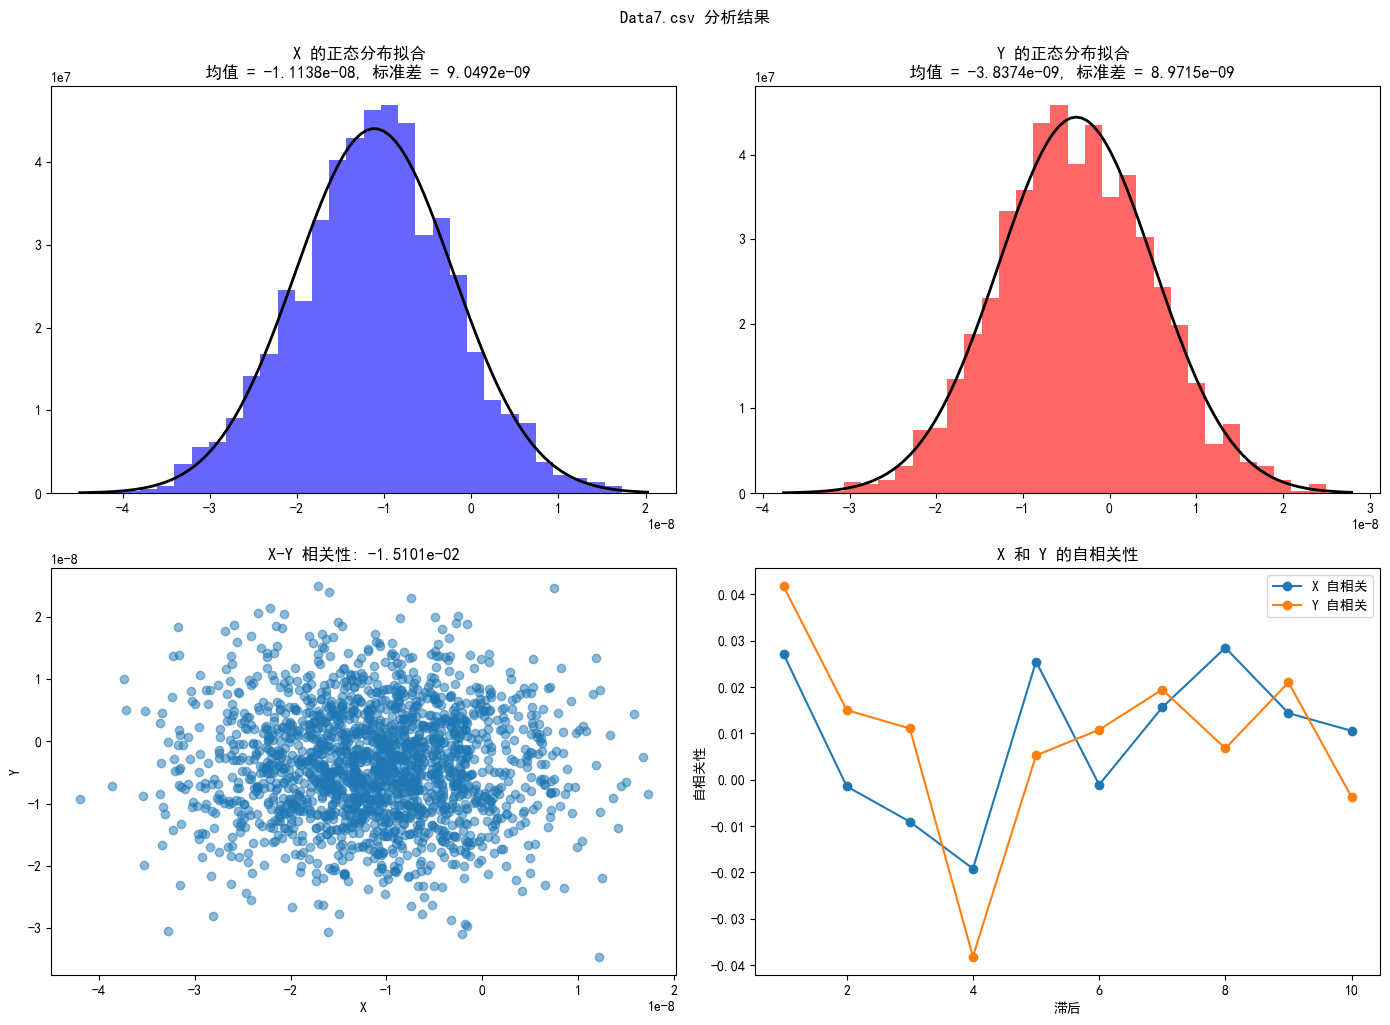

D1-TaLEs-Second-remote\Data8.csv - X-Y 相关性: -0.016784922645374383
D1-TaLEs-Second-remote\Data8.csv - X 数据自相关性: 0.024271081375253616
D1-TaLEs-Second-remote\Data8.csv - Y 数据自相关性: -0.015802732220975887
D1-TaLEs-Second-remote\Data8.csv - 简化卡方值: 20.398187361465205, p 值: 0.015607919096609968


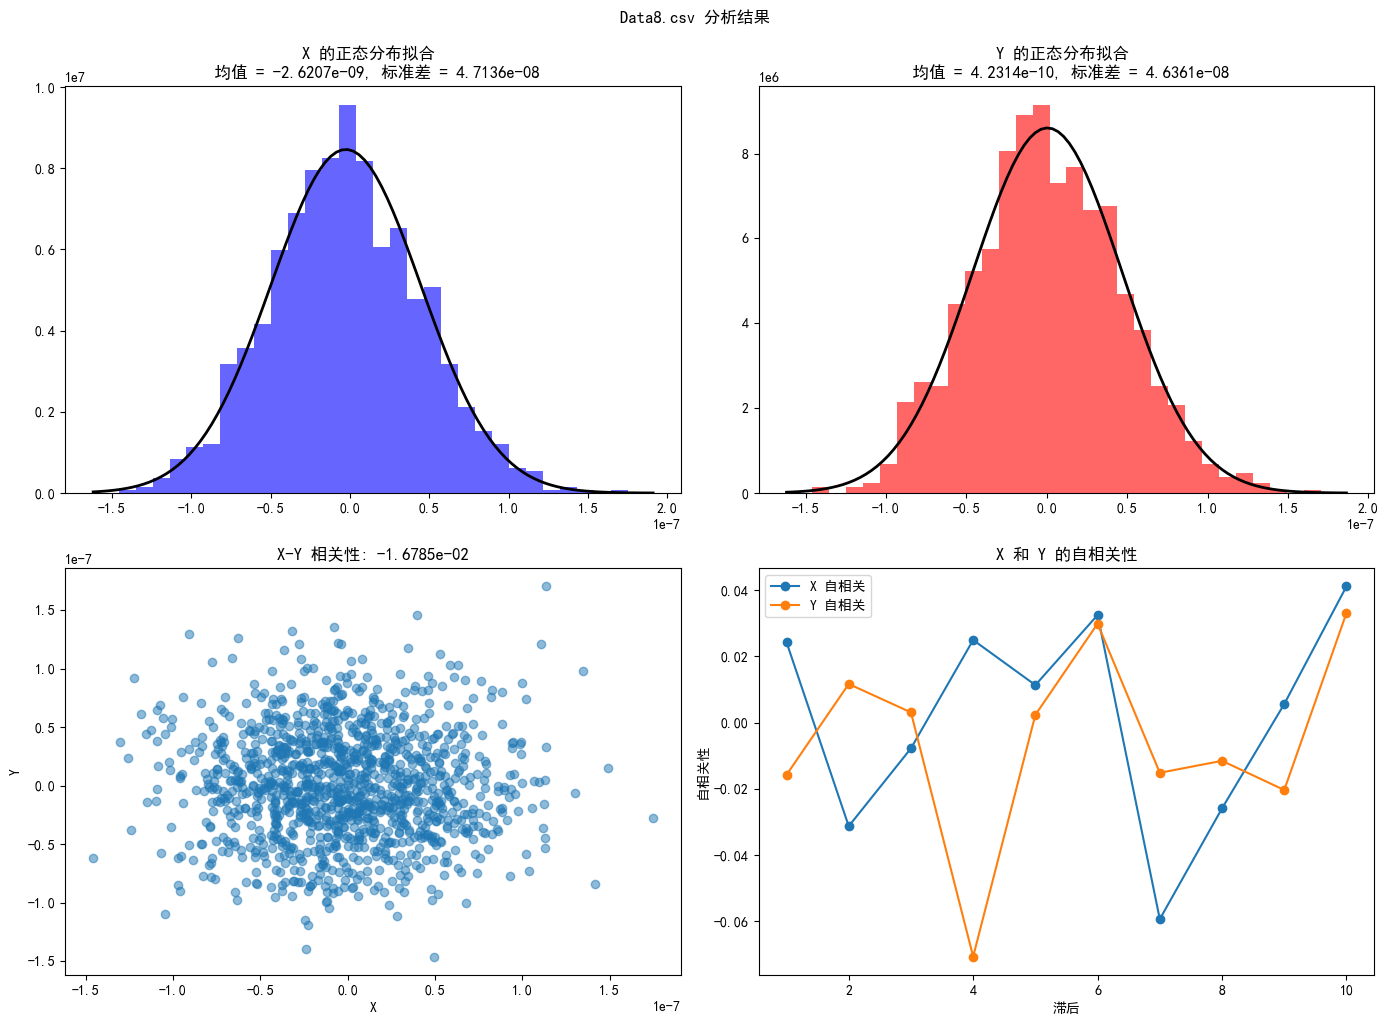

D1-TaLEs-Second-remote\Data9.csv - X-Y 相关性: 0.01948398185206864
D1-TaLEs-Second-remote\Data9.csv - X 数据自相关性: 0.03341513157574634
D1-TaLEs-Second-remote\Data9.csv - Y 数据自相关性: -0.005191187542783691
D1-TaLEs-Second-remote\Data9.csv - 简化卡方值: 179.552380754094, p 值: 6.283282206673121e-34


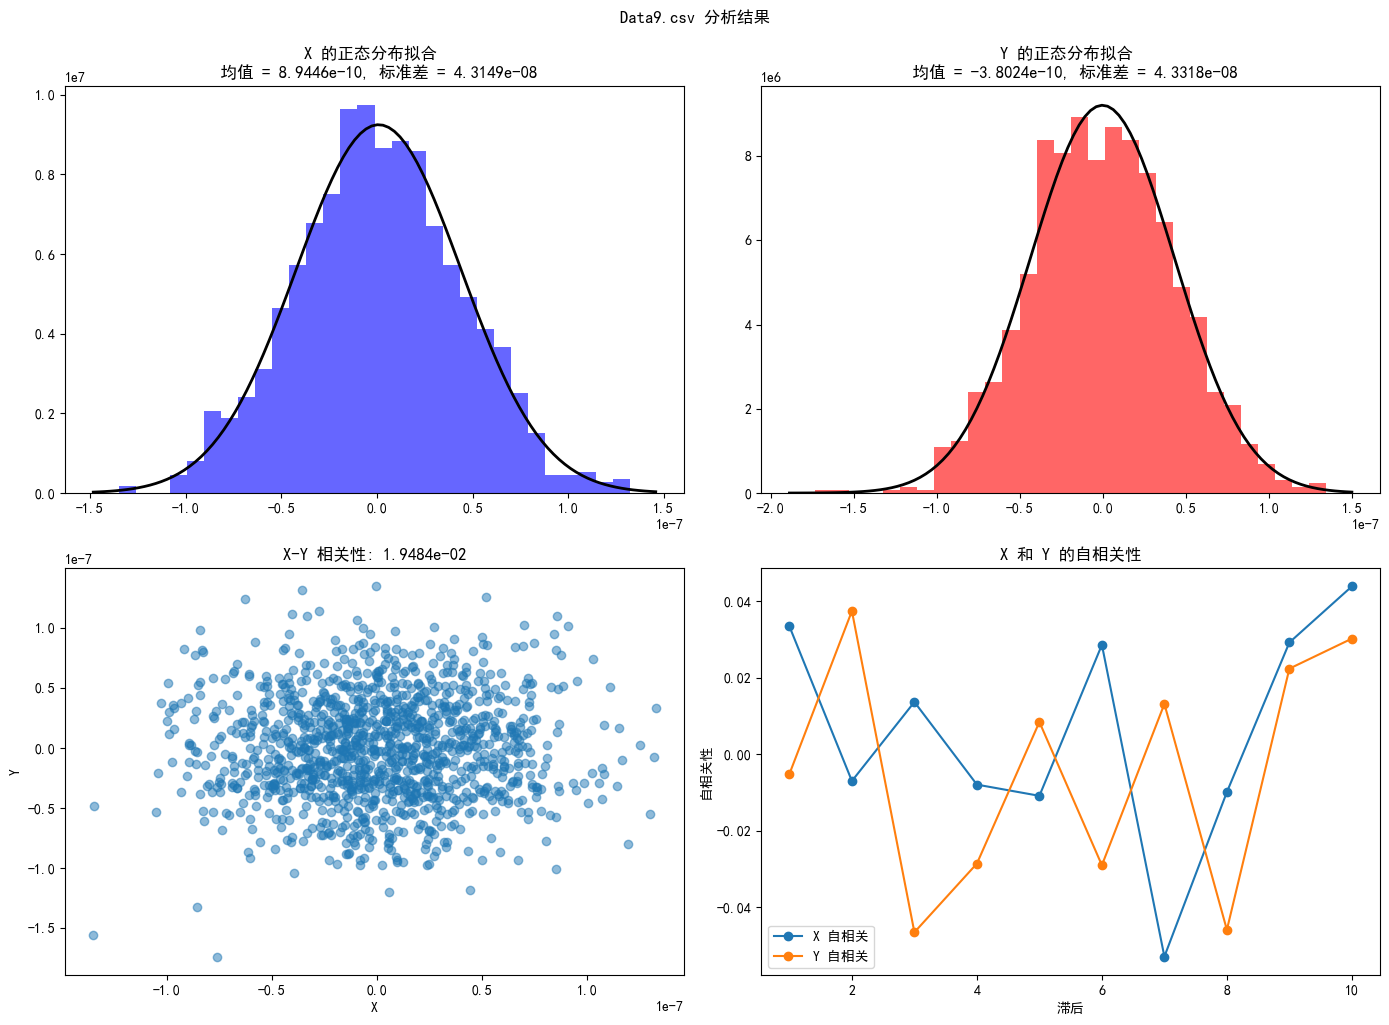

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from glob import glob
import os

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 自相关性函数
def autocorrelation(data, lag=1):
    return np.corrcoef(data[:-lag], data[lag:])[0, 1]

# 定义分析函数
def analyze_file(file_path):
    # 读取CSV文件
    data = pd.read_csv(file_path, skiprows=1)
    
    # 将 X 和 Y 转换为数值类型，忽略非数值内容并用 NaN 替代
    X = pd.to_numeric(data.iloc[:, 0], errors='coerce')
    Y = pd.to_numeric(data.iloc[:, 1], errors='coerce')
    
    # 删除包含 NaN 的行
    X = X.dropna().reset_index(drop=True)
    Y = Y.dropna().reset_index(drop=True)
    
    # 确保 X 和 Y 的长度一致
    min_length = min(len(X), len(Y))
    X = X[:min_length]
    Y = Y[:min_length]

    # 计算相关性
    correlation = np.corrcoef(X, Y)[0, 1]
    print(f"{file_path} - X-Y 相关性: {correlation}")

    # 计算 X 和 Y 的自相关性
    autocorr_X = autocorrelation(X)
    autocorr_Y = autocorrelation(Y)
    print(f"{file_path} - X 数据自相关性: {autocorr_X}")
    print(f"{file_path} - Y 数据自相关性: {autocorr_Y}")

    # 正态分布拟合
    mu_X, std_X = stats.norm.fit(X)
    mu_Y, std_Y = stats.norm.fit(Y)

    # 绘制图形
    plt.figure(figsize=(14, 10))

    # X 的正态分布拟合
    plt.subplot(2, 2, 1)
    plt.hist(X, bins=30, density=True, alpha=0.6, color='blue')
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu_X, std_X)
    plt.plot(x, p, 'k', linewidth=2)
    plt.title(f'X 的正态分布拟合 \n 均值 = {mu_X:.4e}, 标准差 = {std_X:.4e}')

    # Y 的正态分布拟合
    plt.subplot(2, 2, 2)
    plt.hist(Y, bins=30, density=True, alpha=0.6, color='red')
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu_Y, std_Y)
    plt.plot(x, p, 'k', linewidth=2)
    plt.title(f'Y 的正态分布拟合 \n 均值 = {mu_Y:.4e}, 标准差 = {std_Y:.4e}')

    # 卡方检验
    bins = 10
    X_binned, _ = np.histogram(X, bins=bins)
    Y_binned, _ = np.histogram(Y, bins=bins)
    chi2_val, p_val = stats.chisquare(Y_binned, f_exp=X_binned)
    print(f"{file_path} - 简化卡方值: {chi2_val}, p 值: {p_val}")

    # X-Y 散点图
    plt.subplot(2, 2, 3)
    plt.scatter(X, Y, alpha=0.5)
    plt.title(f"X-Y 相关性: {correlation:.4e}")
    plt.xlabel("X")
    plt.ylabel("Y")

    # 自相关性图
    lags = range(1, 11)
    autocorr_X_vals = [autocorrelation(X, lag) for lag in lags]
    autocorr_Y_vals = [autocorrelation(Y, lag) for lag in lags]
    plt.subplot(2, 2, 4)
    plt.plot(lags, autocorr_X_vals, marker='o', label="X 自相关")
    plt.plot(lags, autocorr_Y_vals, marker='o', label="Y 自相关")
    plt.xlabel("滞后")
    plt.ylabel("自相关性")
    plt.title("X 和 Y 的自相关性")
    plt.legend()

    plt.tight_layout()
    plt.suptitle(f"{os.path.basename(file_path)} 分析结果", y=1.02)
    plt.show()

# 批量读取 CSV 文件路径
csv_files = glob('D1-TaLEs-Second-remote/*.csv')  # 替换为文件所在目录

# 对每个 CSV 文件执行分析
for file_path in csv_files:
    analyze_file(file_path)
